# Coral Reef and Tourism 2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
uploaded = files.upload()



Saving MetricsVisits_new.csv to MetricsVisits_new (1).csv


In [ ]:
data = pd.read_csv("MetricsVisits_new.csv",  sep=',')

In [ ]:
data.head()

,Quarter,Year,Quarters,Year-Quarter,AvgTurbidity,AvgCyclone_Frequency,AvgClimSST,AvgSSTA,AvgSTA_Frequency,AvgSSTA_DHW,AvgTSA,AvgTSA_Frequency,AvgTSA_DHW,GSP,GDP,overnight_trips,YQ
0,Apr-Jun 1998,1998,Q2,1998Q2,0.097887,45.655839,297.582213,0.844711,6.715027,8.693039,-1.288503,4.205064,6.465413,50213,322130,3241.320156,1998-04-01
1,Apr-Jun 2002,2002,Q2,2002Q2,0.074600,43.824824,298.450000,0.085556,8.555556,1.775556,-2.108889,0.888889,0.852222,60305,375821,3356.767278,2002-04-01
2,Apr-Jun 2003,2003,Q2,2003Q2,0.081024,50.711967,298.060625,0.178750,2.687500,1.673125,-2.230000,1.187500,1.286250,64275,384012,3849.024509,2003-04-01
3,Apr-Jun 2004,2004,Q2,2004Q2,0.059011,52.968881,297.994444,-0.284444,1.777778,0.144444,-3.050000,0.444444,0.144444,72103,401957,3877.452624,2004-04-01
4,Apr-Jun 2005,2005,Q2,2005Q2,0.079991,45.519537,298.085000,-0.152500,10.250000,10.832500,-1.680000,10.000000,10.260000,76105,414206,3581.705719,2005-04-01


In [ ]:
# Convert to PeriodIndex with quarterly frequency
data["Year-Quarter"] = data["Year-Quarter"].str.replace(" ", "-")
data["Year-Quarter"] = pd.PeriodIndex(data["Year-Quarter"], freq="Q")

# Convert to timestamp (default is end of quarter)
data["YQ"] = data["Year-Quarter"].dt.to_timestamp()

AttributeError: Can only use .str accessor with string values!

In [ ]:
data=data.drop(['Quarter','Year','Year-Quarter'],axis=1)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Quarters              61 non-null     object        
 1   AvgTurbidity          61 non-null     float64       
 2   AvgCyclone_Frequency  61 non-null     float64       
 3   AvgClimSST            61 non-null     float64       
 4   AvgSSTA               61 non-null     float64       
 5   AvgSTA_Frequency      61 non-null     float64       
 6   AvgSSTA_DHW           61 non-null     float64       
 7   AvgTSA                61 non-null     float64       
 8   AvgTSA_Frequency      61 non-null     float64       
 9   AvgTSA_DHW            61 non-null     float64       
 10  GSP                   61 non-null     int64         
 11  GDP                   61 non-null     int64         
 12  overnight_trips       61 non-null     float64       
 13  YQ                    

In [ ]:
# Define categorical columns that represent discrete values
categorical = ['Quarters']

# Define continuous (numerical) columns that represent measurable quantities
continuous = ['AvgTurbidity','AvgCyclone_Frequency','AvgClimSST','AvgSSTA','AvgSTA_Frequency','AvgSSTA_DHW','AvgTSA','AvgTSA_Frequency',
             'AvgTSA_DHW','GSP','GDP','overnight_trips']

# Convert categorical columns to the "category" data type for efficient processing

for i in categorical:
    data[i] = data[i].astype("category")

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Quarters              61 non-null     category      
 1   AvgTurbidity          61 non-null     float64       
 2   AvgCyclone_Frequency  61 non-null     float64       
 3   AvgClimSST            61 non-null     float64       
 4   AvgSSTA               61 non-null     float64       
 5   AvgSTA_Frequency      61 non-null     float64       
 6   AvgSSTA_DHW           61 non-null     float64       
 7   AvgTSA                61 non-null     float64       
 8   AvgTSA_Frequency      61 non-null     float64       
 9   AvgTSA_DHW            61 non-null     float64       
 10  GSP                   61 non-null     int64         
 11  GDP                   61 non-null     int64         
 12  overnight_trips       61 non-null     float64       
 13  YQ                    

### Correlation Matrix

<Axes: >

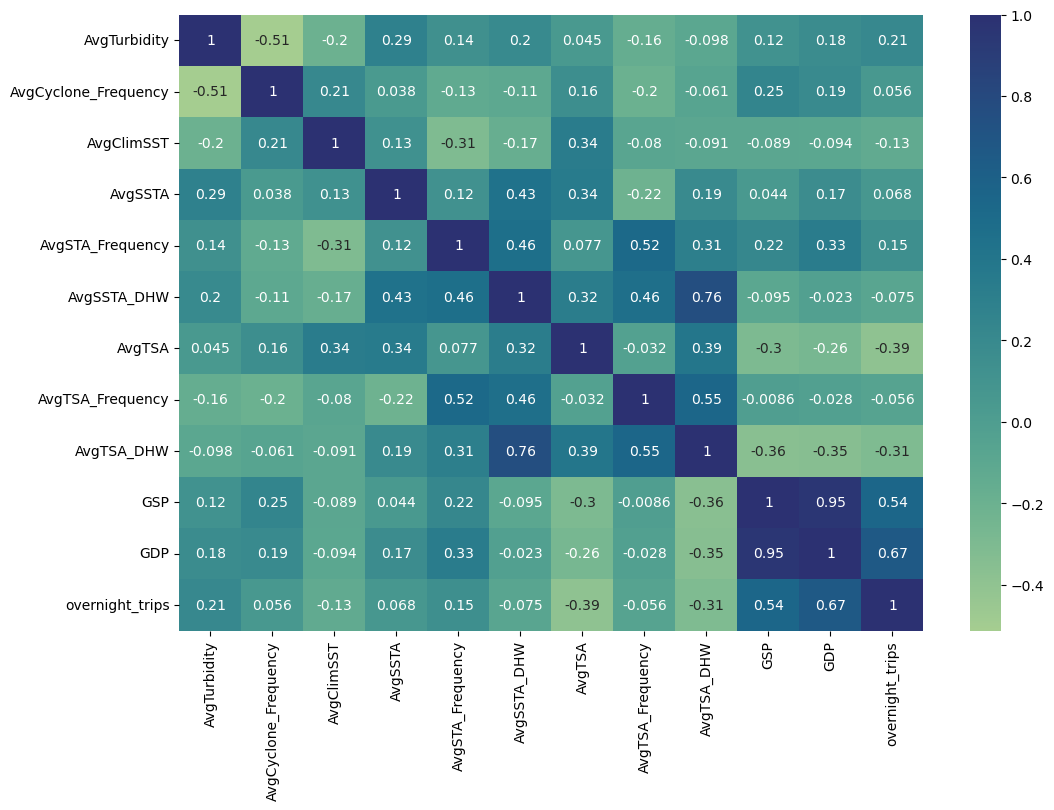

In [ ]:
# Compute the correlation matrix for continuous numerical variables
corr=data[continuous].corr()
# Create a figure and axis for the heatmap with a specified size
f,ax=plt.subplots(figsize=(12,8))
# Generate a heatmap to visualize correlations between numerical features
# 'annot=True' displays correlation values inside the heatmap cells
sns.heatmap(corr,cmap="crest",annot=True)

Text(0.5, 0.98, 'overnight_trips Boxplot')

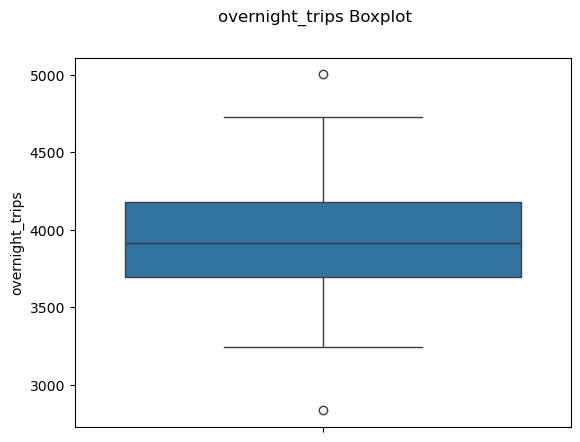

In [ ]:
sns.boxplot(data=data['overnight_trips'])
plt.suptitle('overnight_trips Boxplot')

### Define the test and train set

In [ ]:
from sklearn.model_selection import train_test_split

label = 'overnight_trips'
features = [column for column in data.columns if column != label and column != 'YQ']

X, y = data[features], data[label]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=40) # Hold out validation on the outside

X_train.shape,y_train.shape

((48, 12), (48,))

### Average
Calculate the MAE of a simple model (like always predicting the average) and see if complex model beats it.

In [ ]:
from sklearn.metrics import mean_absolute_error

mae_avg = mean_absolute_error(y_test, [y_train.mean()]*len(y_test))
print(mae_avg)

405.84678709935906


## Linear Regression with Forward Stepwise Feature Selection

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold

categorical = ['Quarters']
continuous = ['AvgTurbidity','AvgCyclone_Frequency','AvgClimSST','AvgSSTA','AvgSTA_Frequency','AvgSSTA_DHW','AvgTSA','AvgTSA_Frequency',
             'AvgTSA_DHW','GSP','GDP','overnight_trips']

#support for 1-hot-encoded features using get_model
#We separate the categorical from the numerical
def get_model(features):
    categorical_features = [col for col in features if col in categorical]
    numerical_features = [col for col in features if col in continuous]
    return make_pipeline(
        ColumnTransformer(transformers=[
            ('categorical', OneHotEncoder(), categorical_features),
            ('numerical', StandardScaler(), numerical_features)
        ]),
        LinearRegression())

# 5-fold CV
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

### Variable selection with stepwise forward selection

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error
import numpy as np

class Solution:
    features = list()
    mae = float('Inf')

    def __init__(self, y):
        pred = [y.mean()] * len(y)
        self.mae = mean_absolute_error(y, pred)

    def update(self, features, mae):
        if mae < self.mae:
            self.features = features
            self.mae = mae
            return True
        return False


all_features = list(features)
current_features = list() #start with empty model
best = Solution(y) #initialize solution

while current_features != all_features:
    selected_feature = None

    for feature in set(all_features) - set(current_features):
        new_features = current_features + [feature] #add one feature at a time
        maes = cross_val_score(
            estimator=get_model(new_features),
            X=X_train[new_features], y=y_train,
            cv=kfold, scoring='neg_mean_absolute_error')
        mae = -np.average(maes)

        if best.update(new_features, mae):
            selected_feature = feature

    if selected_feature:
        current_features.append(selected_feature)
    else:
        break

best_features_lin = best.features

print('Selected features: ', end='')
print(', '.join(best_features_lin))
print(f'MAE feature selection: {round(mae,4)}')


Selected features: GDP, GSP, AvgTSA
MAE feature selection: 236.0805


In [ ]:
categorical_features_lin = []
numerical_features_lin = []

for feature in best_features_lin:
    for cat_feature in categorical:
        if feature == cat_feature:
            categorical_features_lin.append(feature)
    for num_feature in continuous:
        if feature == num_feature:
            numerical_features_lin.append(feature)

linear_reg = make_pipeline(
    ColumnTransformer(transformers=[
        ('categorical', OneHotEncoder(), categorical_features_lin),
        ('numerical', StandardScaler(), numerical_features_lin)
    ]),
    LinearRegression())

# Train model with selected features
linear_reg.fit(X_train[best_features_lin], y_train)

# Make predictions
y_pred_lin = linear_reg.predict(X_test)

# Calculate MAE
print(f"MAE linear regression: {mean_absolute_error(y_test, y_pred_lin)}")

MAE linear regression: 180.9722552741411


In [ ]:
for element in list(zip(linear_reg.steps[1][1].coef_, best_features_lin)):
    print(f"Coeff {element[1]}: {element[0]}")

Coeff GDP: 571.0081443638201
Coeff GSP: -366.42551552641976
Coeff AvgTSA: -111.89472452983362


## Lasso degree 2

In [ ]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

categorical = ['Quarters']
continuous = ['AvgTurbidity','AvgCyclone_Frequency','AvgClimSST','AvgSSTA','AvgSTA_Frequency','AvgSSTA_DHW','AvgTSA','AvgTSA_Frequency',
             'AvgTSA_DHW','GSP','GDP']

Lasso_reg_d2= make_pipeline(
    ColumnTransformer(transformers=[
        ('categorical', OneHotEncoder(), categorical),
        ('numerical', StandardScaler(), continuous)
    ]),
    PolynomialFeatures(degree=2),
    GridSearchCV(estimator=Lasso(max_iter=100000),
                 param_grid=dict(alpha=np.logspace(-3, 5, 50)),
                 cv=kfold, scoring='neg_mean_absolute_error')
)

# Train model with selected features
Lasso_reg_d2.fit(X_train, y_train)

# Make predictions
y_pred_lasso_d2 = Lasso_reg_d2.predict(X_test)

# Calculate MAE
mean_absolute_error(y_test, y_pred_lasso_d2)

267.0626233388662

In [ ]:
y_pred_lasso_d2

array([3831.02814603, 3854.77468861, 3840.01521377, 3415.88333632,
       3795.94987261, 4180.88585055, 3997.33506902, 4368.15788764,
       3549.8658673 , 4083.97151319, 3822.94644594, 4158.06155742,
       3350.83243937])

In [ ]:
# Get the best Lasso model from GridSearchCV
best_lasso_d2 = Lasso_reg_d2.named_steps['gridsearchcv'].best_estimator_

# Get coefficients
coefficients_lasso_d2 = best_lasso_d2.coef_

print(f"Best alpha: {Lasso_reg_d2.named_steps['gridsearchcv'].best_params_['alpha']}")
print(f"\nTotal features: {len(coefficients_lasso_d2)}")
print(f"Non-zero coefficients: {np.sum(coefficients_lasso_d2 != 0)}")

Best alpha: 54.286754393238596

Total features: 136
Non-zero coefficients: 10


In [ ]:
column_transform = Lasso_reg_d2.named_steps['columntransformer']
poly = Lasso_reg_d2.named_steps['polynomialfeatures']

# Get feature names from ColumnTransformer
feature_names = column_transform.get_feature_names_out()

# Get polynomial feature names
poly_feature_names = poly.get_feature_names_out(feature_names)

# Create DataFrame with non-zero coefficients
coef_df_lasso_d2 = pd.DataFrame({'feature': poly_feature_names, 'coefficient': coefficients_lasso_d2})
print("Non-zero coefficients:")
display(coef_df_lasso_d2[coef_df_lasso_d2["coefficient"]!=0])

Non-zero coefficients:


,feature,coefficient
11,numerical__AvgTSA,-15.675648
15,numerical__GDP,175.900533
89,numerical__AvgCyclone_Frequency numerical__GSP,-1.461966
100,numerical__AvgSSTA^2,-1.870917
111,numerical__AvgSTA_Frequency numerical__AvgTSA_...,55.859433
114,numerical__AvgSTA_Frequency numerical__GDP,43.171001
121,numerical__AvgTSA^2,19.786716
127,numerical__AvgTSA_Frequency numerical__AvgTSA_DHW,-23.092453
130,numerical__AvgTSA_DHW^2,-2.155508
135,numerical__GDP^2,16.127588


## Lasso degree 1

In [ ]:
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

categorical = ['Quarters']
continuous = ['AvgTurbidity','AvgCyclone_Frequency','AvgClimSST','AvgSSTA','AvgSTA_Frequency','AvgSSTA_DHW','AvgTSA','AvgTSA_Frequency',
             'AvgTSA_DHW','GSP','GDP']

Lasso_reg_d1= make_pipeline(
    ColumnTransformer(transformers=[
        ('categorical', OneHotEncoder(), categorical),
        ('numerical', StandardScaler(), continuous)
    ]),
    GridSearchCV(estimator=Lasso(max_iter=100000),
                 param_grid=dict(alpha=np.logspace(-3, 5, 50)),
                 cv=kfold, scoring='neg_mean_absolute_error')
)

# Train model with selected features
Lasso_reg_d1.fit(X_train, y_train)

# Make predictions
y_pred_lasso_d1 = Lasso_reg_d1.predict(X_test)

# Calculate MAE
mean_absolute_error(y_test, y_pred_lasso_d1)

260.2402707213351

In [ ]:
# Get the best Lasso model from GridSearchCV
best_lasso_d1 = Lasso_reg_d1.named_steps['gridsearchcv'].best_estimator_

# Get coefficients
coefficients_lasso_d1 = best_lasso_d1.coef_

print(f"Best alpha: {Lasso_reg_d1.named_steps['gridsearchcv'].best_params_['alpha']}")
print(f"\nTotal features: {len(coefficients_lasso_d1)}")
print(f"Non-zero coefficients: {np.sum(coefficients_lasso_d1 != 0)}")

# Get feature names
column_transform = Lasso_reg_d1.named_steps['columntransformer']
feature_names = column_transform.get_feature_names_out()

# Create DataFrame with non-zero coefficients
coef_df_lasso_d1 = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients_lasso_d1})
display(coef_df_lasso_d1[coef_df_lasso_d1["coefficient"]!=0])

Best alpha: 54.286754393238596

Total features: 15
Non-zero coefficients: 2


,feature,coefficient
10,numerical__AvgTSA,-45.058258
14,numerical__GDP,180.095221


## Ridge

In [ ]:
from sklearn.linear_model import Ridge

kfold = KFold(n_splits=5, shuffle=True, random_state=0)

categorical = ['Quarters']
continuous = ['AvgTurbidity','AvgCyclone_Frequency','AvgClimSST','AvgSSTA','AvgSTA_Frequency','AvgSSTA_DHW','AvgTSA','AvgTSA_Frequency',
             'AvgTSA_DHW','GSP','GDP']

Ridge_reg= make_pipeline(
    ColumnTransformer(transformers=[
        ('categorical', OneHotEncoder(), categorical),
        ('numerical', StandardScaler(), continuous)
    ]),
    GridSearchCV(estimator=Ridge(max_iter=100000),
                 param_grid=dict(alpha=np.logspace(-3, 5, 50)),
                 cv=kfold, scoring='neg_mean_absolute_error')
)

# Train model with selected features
Ridge_reg.fit(X_train, y_train)

# Make predictions
y_pred_ridge = Ridge_reg.predict(X_test)

# Calculate MAE
mean_absolute_error(y_test, y_pred_ridge)

300.19251307943244

In [ ]:
# Get the best Ridge model from GridSearchCV
best_ridge = Ridge_reg.named_steps['gridsearchcv'].best_estimator_

# Get coefficients
coefficients = best_ridge.coef_

print(f"Best alpha: {Ridge_reg.named_steps['gridsearchcv'].best_params_['alpha']}")
print(f"\nTotal features: {len(coefficients)}")
print(f"Non-zero coefficients: {np.sum(coefficients != 0)}")

# Get feature names
column_transform = Ridge_reg.named_steps['columntransformer']
feature_names = column_transform.get_feature_names_out()

# Create DataFrame with non-zero coefficients
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefficients})
display(coef_df[coef_df["coefficient"]!=0])

Best alpha: 79.06043210907686

Total features: 15
Non-zero coefficients: 15


,feature,coefficient
0,categorical__Quarters_Q1,-1.177796
1,categorical__Quarters_Q2,-17.830185
2,categorical__Quarters_Q3,20.465377
3,categorical__Quarters_Q4,-1.457395
4,numerical__AvgTurbidity,13.048370
5,numerical__AvgCyclone_Frequency,1.960834
6,numerical__AvgClimSST,-15.996971
7,numerical__AvgSSTA,6.610007
8,numerical__AvgSTA_Frequency,15.606841
9,numerical__AvgSSTA_DHW,-2.607519


## Predict on new data set

A new data set is provided for the year 2018, with expected metrics (provided by NOAA) and overnight trips (forecasted by Australian Trade and Investment Commission). The idea is to compare that forecast with the prediction of this model.

In [ ]:
data_expected = pd.read_csv("MetricsVisits_new_expected.csv",  sep=',')
data_expected

,Quarter,Year,Quarters,Year-Quarter,AvgTurbidity,AvgCyclone_Frequency,AvgClimSST,AvgSSTA,AvgSTA_Frequency,AvgSSTA_DHW,AvgTSA,AvgTSA_Frequency,AvgTSA_DHW,GSP,GDP,overnight_trips
0,Jan-Mar 2018,2018,Q1,2018 Q1,NaN,NaN,NaN,NaN,NaN,NaN,0.254315,NaN,NaN,103800,565896,4721.458084
1,Apr-Jun 2018,2018,Q2,2018 Q2,NaN,NaN,NaN,NaN,NaN,NaN,-3.706948,NaN,NaN,111744,599780,4743.702688
2,Jul-Sep 2018,2018,Q3,2018 Q3,NaN,NaN,NaN,NaN,NaN,NaN,-5.194148,NaN,NaN,108649,597624,5439.643404
3,Oct-Dec 2018,2018,Q4,2018 Q4,NaN,NaN,NaN,NaN,NaN,NaN,-2.205726,NaN,NaN,113315,618991,5090.796824


In [ ]:
label_exp = 'overnight_trips'

features_exp = ['Quarters', 'AvgSSTA', 'AvgCyclone_Frequency', 'AvgTSA_Frequency', 'AvgSSTA_DHW', 'AvgTurbidity',
                'AvgClimSST', 'AvgTSA_DHW', 'AvgSTA_Frequency','AvgTSA','GSP','GDP']

X_exp, y_exp = data_expected[features_exp], data_expected[label_exp]

X_exp.shape,y_exp.shape

((4, 12), (4,))

In [ ]:
Last_year=['2017-01-01 00:00:00','2017-04-01 00:00:00','2017-07-01 00:00:00','2017-10-01 00:00:00']
Last_year_df = data[data["YQ"].isin(Last_year)]
print(f"Overnight trips in 2017: {Last_year_df['overnight_trips'].sum()}")
print(f"Expected overnight trips in 2018: {data_expected["overnight_trips"].sum()}")
print(f"Difference in percentage: {round(((data_expected["overnight_trips"].sum() - Last_year_df['overnight_trips'].sum())
                           /Last_year_df['overnight_trips'].sum()) * 100,2)}%")


Overnight trips in 2017: 18388.413784
Expected overnight trips in 2018: 19995.601
Difference in percentage: 8.74%


C:\Users\Sergio\AppData\Local\Temp\ipykernel_26836\890348163.py:2: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  Last_year_df = data[data["YQ"].isin(Last_year)]


#### Linear Regression

In [ ]:
# Make predictions
y_pred_lin_exp = linear_reg.predict(X_exp)

In [ ]:
# Show results
results_linear = pd.DataFrame({'y_exp': y_exp, 'model prediction': y_pred_lin_exp})
totals = results_linear.sum()
pct_diff = ((totals['model prediction'] - totals['y_exp'])/ totals['y_exp']) * 100
results_totals_linear = results_linear.copy()
results_totals_linear.loc['Total'] = totals
#results_totals_linear.loc['% Diff'] = [None, pct_diff]

Diff_2018_exp = round(((y_exp.sum() - Last_year_df['overnight_trips'].sum())
                       /Last_year_df['overnight_trips'].sum()) * 100,2)
Diff_2018_pred = round(((y_pred_lin_exp.sum() - Last_year_df['overnight_trips'].sum())
                       /Last_year_df['overnight_trips'].sum()) * 100,2)

results_totals_linear.loc['% Diff with 2017'] = [Diff_2018_exp, Diff_2018_pred]

display(results_totals_linear)

,y_exp,model prediction
0,4721.458084,4265.328577
1,4743.702688,4599.470039
2,5439.643404,4735.525568
3,5090.796824,4646.766969
Total,19995.601000,18247.091154
% Diff with 2017,8.740000,-0.770000
